# 📊 EDA — Análisis Exploratorio de Datos
## YouTube Hate Speech Detection

**Objetivo:** Entender el dataset antes de modelar. Cada sección termina con una conclusión documentada.

**Dataset:** YouTube Comments — 1000 filas × 15 columnas  
**Target principal:** `IsToxic` (binario)  
**Sublabels:** IsAbusive, IsProvocative, IsHatespeech, IsRacist, IsObscene

---
> **Regla de oro:** No se toca el preprocesamiento aquí. Solo se analiza y se documentan conclusiones.


## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

# Estilo global
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print("✅ Imports correctos")


✅ Imports correctos


## 1. Carga del dataset

Cargamos el CSV y hacemos una primera inspección estructural.


In [2]:
# ── Ajusta esta ruta si tu CSV tiene otro nombre ──
DATA_PATH = "../data/raw/youtoxic_english_1000.csv"

df = pd.read_csv(DATA_PATH)

print(f"📐 Shape: {df.shape}")
print(f"📋 Columnas: {df.columns.tolist()}")
print()
df.head(3)


📐 Shape: (1000, 15)
📋 Columnas: ['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']



,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False


In [3]:
# Tipos de datos
df.dtypes


CommentId          object
VideoId            object
Text               object
IsToxic              bool
IsAbusive            bool
IsThreat             bool
IsProvocative        bool
IsObscene            bool
IsHatespeech         bool
IsRacist             bool
IsNationalist        bool
IsSexist             bool
IsHomophobic         bool
IsReligiousHate      bool
IsRadicalism         bool
dtype: object

## 2. Calidad del dataset

Antes de analizar el contenido, verificamos que los datos están limpios a nivel estructural.


In [4]:
# ── CALIDAD — versión rápida ──────────────────────────────────────────────
print("=== NULOS ===")
print(df.isnull().sum())
print()

print(f"=== DUPLICADOS ===")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print()

# str.isascii() es nativo Python — 100x más rápido que regex en pandas
print("=== ENCODING / CARACTERES RAROS ===")
mask_weird = ~df['Text'].astype(str).map(str.isascii)
print(f"Comentarios con caracteres no-ASCII: {mask_weird.sum()}")

if mask_weird.sum() > 0:
    print("\nEjemplos:")
    for t in df.loc[mask_weird, 'Text'].head(3):
        print(repr(t[:120]))


=== NULOS ===
CommentId          0
VideoId            0
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
dtype: int64

=== DUPLICADOS ===
Filas duplicadas: 0

=== ENCODING / CARACTERES RAROS ===
Comentarios con caracteres no-ASCII: 203

Ejemplos:
"If only people would just take a step back and not make this case about them, because it wasn't about anyone except the "
'Law enforcement is not trained to shoot to apprehend. \xa0They are trained to shoot to kill. \xa0And I thank Wilson for killin'
"\nDont you reckon them 'black lives matter' banners being held by white cunts is \xa0kinda patronizing and ironically racist"


In [5]:
# ── CONCLUSIÓN CALIDAD ──────────────────────────────────────────────────────
print("""
CONCLUSIÓN 2 — Calidad:
- Nulos: 0  (acción necesaria: Ninguna)
- Duplicados: 0 (acción: Ninguna)
- Caracteres raros: 203 (acción: limpiar con regex en preprocesamiento)
""")



CONCLUSIÓN 2 — Calidad:
- Nulos: 0  (acción necesaria: Ninguna)
- Duplicados: 0 (acción: Ninguna)
- Caracteres raros: 203 (acción: limpiar con regex en preprocesamiento)



## 3. Distribución del target

Analizamos qué tan balanceado está el dataset. Esto determina si necesitamos técnicas de balanceo (SMOTE, class_weight) y qué métricas usar.


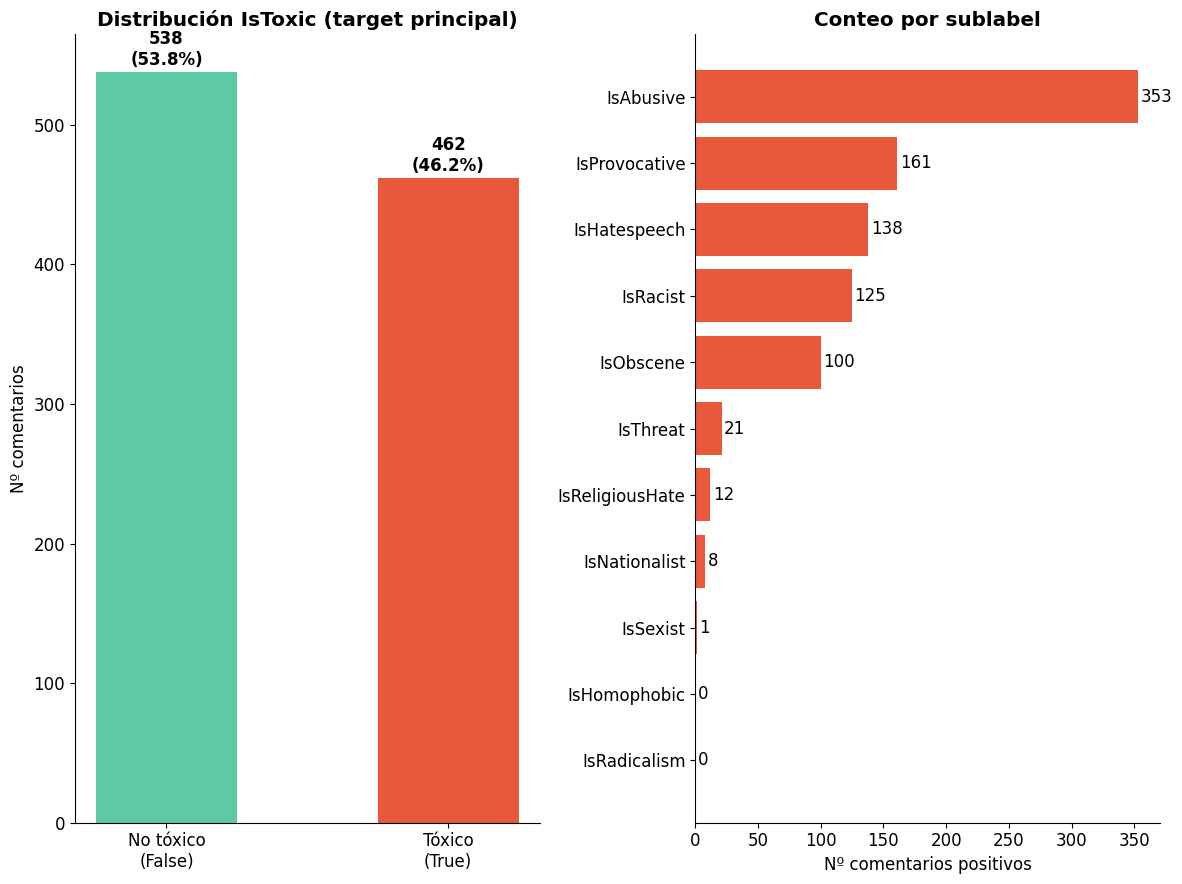

✅ Guardado en reports/01_distribucion_target.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 9))

# IsToxic
counts = df['IsToxic'].value_counts()
colors = ['#5DCAA5', '#E8593C']
axes[0].bar(['No tóxico\n(False)', 'Tóxico\n(True)'], counts.values, color=colors, width=0.5)
axes[0].set_title('Distribución IsToxic (target principal)', fontweight='bold')
axes[0].set_ylabel('Nº comentarios')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Sublabels
sublabels = ['IsAbusive','IsProvocative','IsHatespeech','IsRacist','IsObscene',
             'IsThreat','IsReligiousHate','IsNationalist','IsSexist','IsHomophobic','IsRadicalism']
sub_counts = df[sublabels].sum().sort_values(ascending=True)
colors_sub = ['#E8593C' if v > 0 else '#B4B2A9' for v in sub_counts.values]
axes[1].barh(sub_counts.index, sub_counts.values, color=colors_sub)
axes[1].set_title('Conteo por sublabel', fontweight='bold')
axes[1].set_xlabel('Nº comentarios positivos')
for i, v in enumerate(sub_counts.values):
    axes[1].text(v + 2, i, str(v), va='center')

plt.tight_layout()
plt.savefig('../reports/v2/01_distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado en reports/01_distribucion_target.png")


In [7]:
# ── CONCLUSIÓN DISTRIBUCIÓN ─────────────────────────────────────────────────
toxic_pct = df['IsToxic'].mean() * 100
print(f"""
CONCLUSIÓN 3 — Distribución del target:
- IsToxic True: {toxic_pct:.1f}% → dataset {"BALANCEADO" if 40 < toxic_pct < 60 else "DESBALANCEADO"}
- Sublabels viables (>10 positivos): IsAbusive, IsProvocative, IsHatespeech, IsRacist, IsObscene
- Sublabels inutilizables (<2 positivos): IsHomophobic=0, IsRadicalism=0, IsSexist=1

DECISIÓN: Usar class_weight='balanced' en modelos por precaución.
DECISIÓN: Sublabels con <10 positivos se excluyen del multilabel.
""")



CONCLUSIÓN 3 — Distribución del target:
- IsToxic True: 46.2% → dataset BALANCEADO
- Sublabels viables (>10 positivos): IsAbusive, IsProvocative, IsHatespeech, IsRacist, IsObscene
- Sublabels inutilizables (<2 positivos): IsHomophobic=0, IsRadicalism=0, IsSexist=1

DECISIÓN: Usar class_weight='balanced' en modelos por precaución.
DECISIÓN: Sublabels con <10 positivos se excluyen del multilabel.



## 4. Análisis de longitud de texto

La distribución de longitudes nos dice si necesitamos truncar, si hay outliers extremos y si toxic/no-toxic tienen patrones distintos.


In [8]:
# Longitud en caracteres y en palabras
df['char_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

print("=== CARACTERES ===")
print(df['char_length'].describe().round(1))
print()
print("=== PALABRAS ===")
print(df['word_count'].describe().round(1))


=== CARACTERES ===
count    1000.0
mean      185.6
std       270.8
min         3.0
25%        47.0
50%       101.0
75%       217.0
max      4421.0
Name: char_length, dtype: float64

=== PALABRAS ===
count    1000.0
mean       33.8
std        49.1
min         1.0
25%         9.0
50%        19.0
75%        39.0
max       815.0
Name: word_count, dtype: float64


In [9]:
print("""   -- CARACTERES --
La media > mediana = distribución sesgada
Hay comentarios MUY largos (hasta 4421 caracteres)
Pero no representan el comportamiento típico
      
    -- PALABRAS --
Igual patrón: muchos textos cortos, pocos muy largos
815 palabras es un outlier fuerte
""")

   -- CARACTERES --
La media > mediana = distribución sesgada
Hay comentarios MUY largos (hasta 4421 caracteres)
Pero no representan el comportamiento típico
      
    -- PALABRAS --
Igual patrón: muchos textos cortos, pocos muy largos
815 palabras es un outlier fuerte



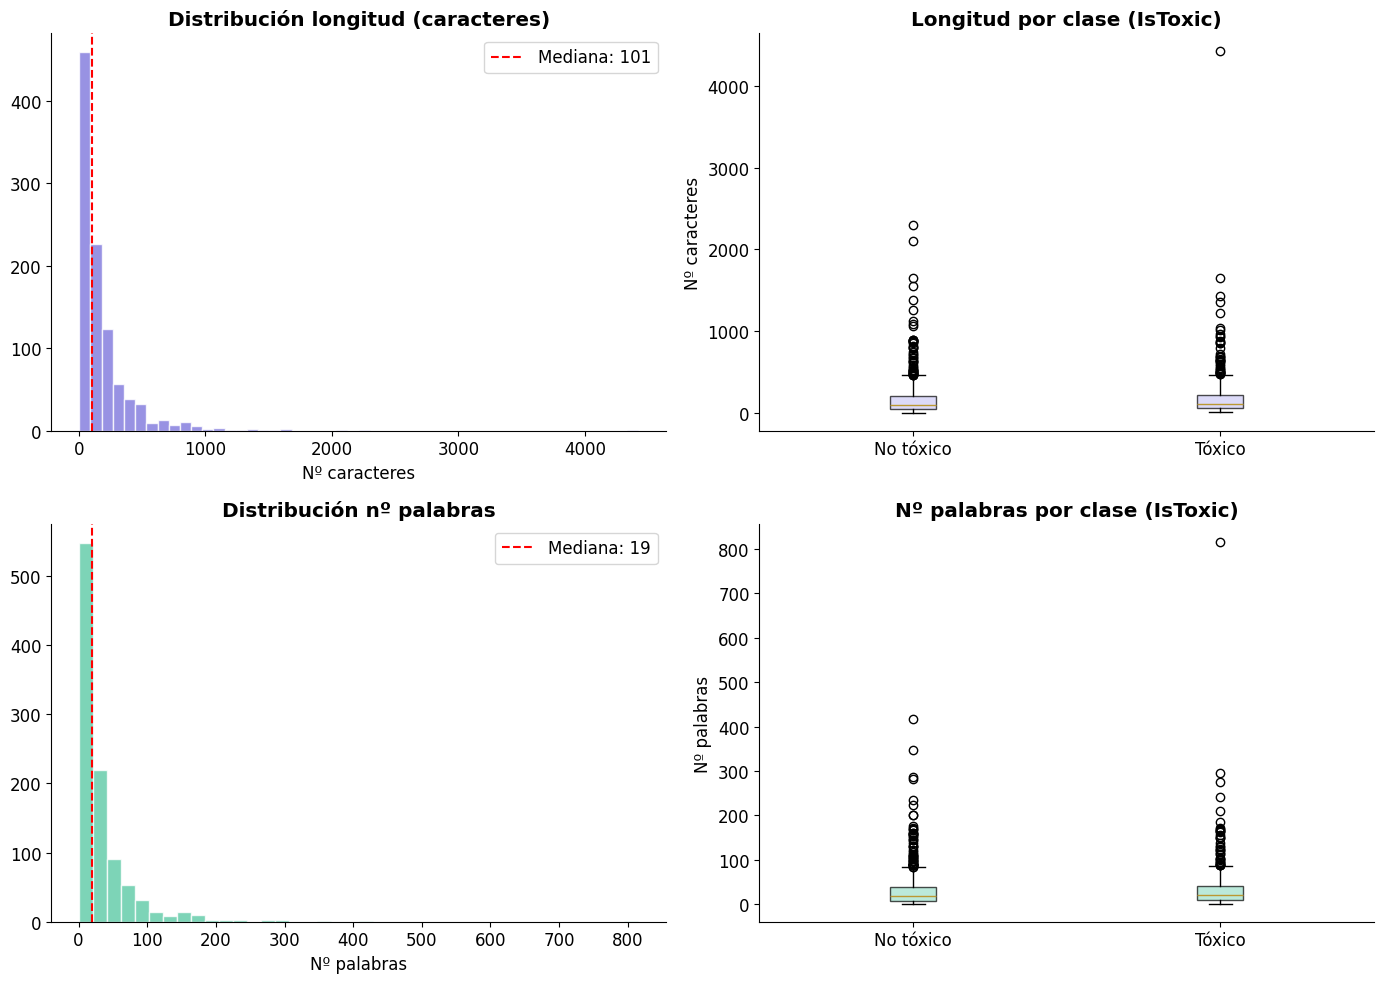

✅ Guardado en reports/02_longitud_texto.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución general de longitud
axes[0,0].hist(df['char_length'], bins=50, color='#7F77DD', alpha=0.8, edgecolor='white')
axes[0,0].axvline(df['char_length'].median(), color='red', linestyle='--', label=f'Mediana: {df["char_length"].median():.0f}')
axes[0,0].set_title('Distribución longitud (caracteres)', fontweight='bold')
axes[0,0].set_xlabel('Nº caracteres')
axes[0,0].legend()

# 2. Longitud por target (boxplot)
toxic_len = df[df['IsToxic']==True]['char_length']
notox_len = df[df['IsToxic']==False]['char_length']
axes[0,1].boxplot([notox_len, toxic_len], labels=['No tóxico', 'Tóxico'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#CECBF6', alpha=0.7))
axes[0,1].set_title('Longitud por clase (IsToxic)', fontweight='bold')
axes[0,1].set_ylabel('Nº caracteres')

# 3. Distribución palabras
axes[1,0].hist(df['word_count'], bins=40, color='#5DCAA5', alpha=0.8, edgecolor='white')
axes[1,0].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'Mediana: {df["word_count"].median():.0f}')
axes[1,0].set_title('Distribución nº palabras', fontweight='bold')
axes[1,0].set_xlabel('Nº palabras')
axes[1,0].legend()

# 4. Palabras por target
axes[1,1].boxplot([df[df['IsToxic']==False]['word_count'],
                   df[df['IsToxic']==True]['word_count']],
                  labels=['No tóxico', 'Tóxico'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#9FE1CB', alpha=0.7))
axes[1,1].set_title('Nº palabras por clase (IsToxic)', fontweight='bold')
axes[1,1].set_ylabel('Nº palabras')

plt.tight_layout()
plt.savefig('../reports/v2/02_longitud_texto.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado en reports/02_longitud_texto.png")


In [11]:
# Outliers extremos (comentarios muy largos)
q99 = df['char_length'].quantile(0.99)
outliers = df[df['char_length'] > q99]
print(f"Comentarios en percentil 99 (>{q99:.0f} chars): {len(outliers)}")
print()
print("Ejemplo comentario más largo:")
print(df.loc[df['char_length'].idxmax(), 'Text'][:300], "...")


Comentarios en percentil 99 (>1220 chars): 10

Ejemplo comentario más largo:
THE UGLY TRUTH:

If you talk like a THUG, act like a THUG, walk like a THUG, and live like a THUG... Then you will die like a THUG!

"Live by the sword die by the sword." - "Don't hate the player, hate the game!"

This was not an innocent little child just walking down the street who got shot in the ...


In [12]:
# ── CONCLUSIÓN LONGITUD ─────────────────────────────────────────────────────
print("""
CONCLUSIÓN 4 — Longitud de texto:
- Alta varianza (std ~270 chars) → algunos comentarios son muy cortos, otros muy largos
- Los comentarios tóxicos tienden a ser: Similar
- Hay outliers extremos en percentil 99 → considerar truncado en vectorización (max_features)
- Mediana ~100 palabras → TF-IDF con ngram(1,2) es apropiado para este rango
""")



CONCLUSIÓN 4 — Longitud de texto:
- Alta varianza (std ~270 chars) → algunos comentarios son muy cortos, otros muy largos
- Los comentarios tóxicos tienden a ser: Similar
- Hay outliers extremos en percentil 99 → considerar truncado en vectorización (max_features)
- Mediana ~100 palabras → TF-IDF con ngram(1,2) es apropiado para este rango



## 5. WordClouds — ¿Qué palabras dominan?

Visualizamos las palabras más frecuentes en comentarios tóxicos vs no tóxicos.  
Esto nos ayuda a entender qué vocabulario caracteriza el hate speech en este dataset.

> ⚠️ Nota: usamos texto **sin limpiar** aquí. El preprocesamiento viene después.


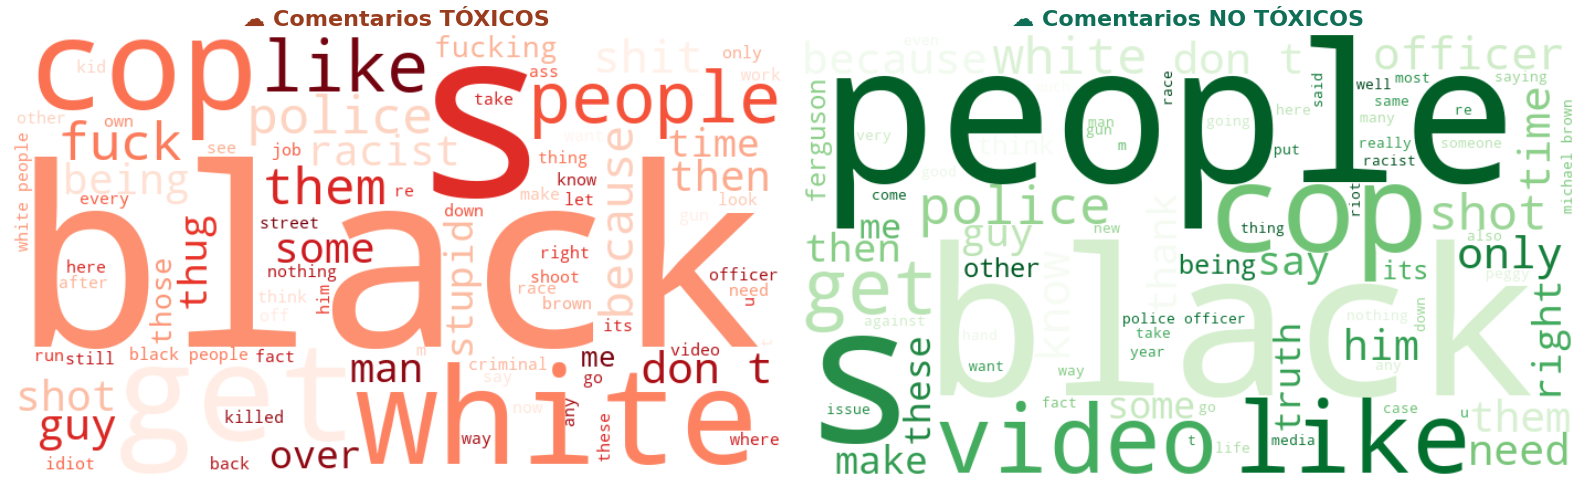

✅ Guardado en reports/v2/03_wordclouds.png


In [13]:
def simple_clean(text):
    """Limpieza mínima solo para visualización — NO es el preprocesamiento final."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'[^a-z\s]', ' ', text)          # solo letras
    return text

toxic_text    = ' '.join(df[df['IsToxic']==True]['Text'].apply(simple_clean))
nontoxic_text = ' '.join(df[df['IsToxic']==False]['Text'].apply(simple_clean))

stopwords_basic = set(['the','a','an','and','or','but','in','on','at','to','for',
                        'of','with','is','it','this','that','are','was','be','have',
                        'has','he','she','they','we','you','i','not','do','did',
                        'will','can','would','should','could','from','by','as','if',
                        'so','all','my','your','his','her','our','their','than',
                        'there','what','who','when','how','why','which','about',
                        'been','were','had','more','one','no','up','out','just'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_toxic = WordCloud(width=700, height=400, background_color='white',
                     colormap='Reds', stopwords=stopwords_basic,
                     max_words=80).generate(toxic_text)

wc_clean = WordCloud(width=700, height=400, background_color='white',
                     colormap='Greens', stopwords=stopwords_basic,
                     max_words=80).generate(nontoxic_text)

axes[0].imshow(wc_toxic, interpolation='bilinear')
axes[0].set_title('☁️ Comentarios TÓXICOS', fontsize=16, fontweight='bold', color='#993C1D')
axes[0].axis('off')

axes[1].imshow(wc_clean, interpolation='bilinear')
axes[1].set_title('☁️ Comentarios NO TÓXICOS', fontsize=16, fontweight='bold', color='#0F6E56')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../reports/v2/03_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado en reports/v2/03_wordclouds.png")


In [14]:
# Top 20 palabras por clase (frecuencia raw)
from collections import Counter

def top_words(text, n=20):
    words = [w for w in text.split() if w not in stopwords_basic and len(w) > 3]
    return Counter(words).most_common(n)

print("TOP 20 — Comentarios TÓXICOS:")
for word, count in top_words(toxic_text):
    print(f"  {word}: {count}")

print()
print("TOP 20 — Comentarios NO TÓXICOS:")
for word, count in top_words(nontoxic_text):
    print(f"  {word}: {count}")


TOP 20 — Comentarios TÓXICOS:
  black: 133
  people: 128
  them: 81
  white: 78
  like: 75
  police: 73
  brown: 55
  fuck: 51
  shot: 50
  because: 48
  shit: 45
  over: 45
  these: 41
  officer: 39
  being: 38
  then: 38
  some: 38
  cops: 34
  fucking: 33
  blacks: 32

TOP 20 — Comentarios NO TÓXICOS:
  people: 130
  black: 121
  police: 104
  like: 78
  video: 61
  white: 61
  officer: 59
  brown: 56
  shot: 45
  because: 42
  only: 41
  know: 41
  these: 40
  them: 38
  cops: 35
  then: 35
  some: 33
  most: 32
  truth: 31
  right: 30


## 6. Correlación entre sublabels

¿Van juntos ciertos tipos de toxicidad? Esto define si tiene sentido hacer multilabel y cuáles sublabels son redundantes.


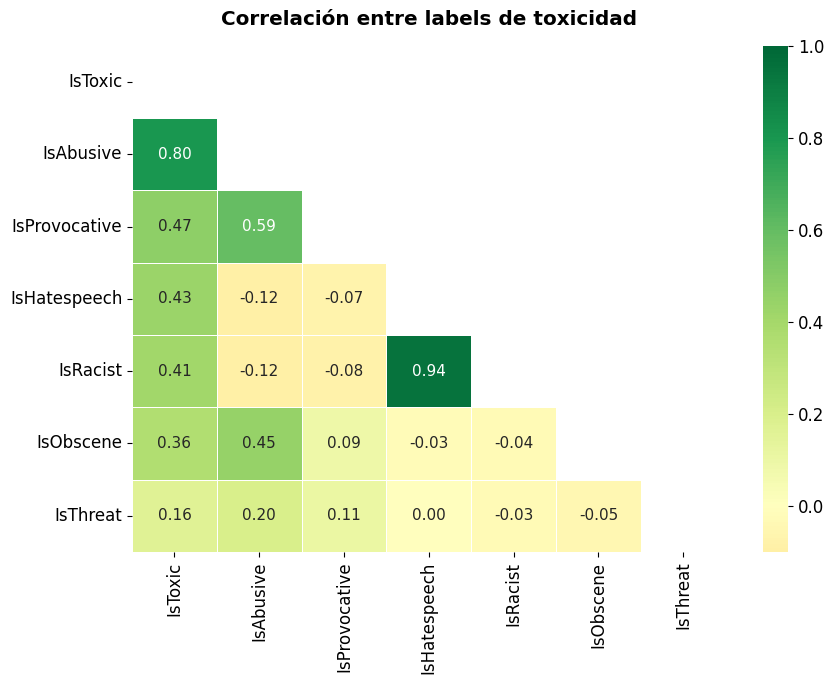

✅ Guardado en reports/v2/04_correlacion_sublabels.png


In [15]:
sublabels_viables = ['IsToxic','IsAbusive','IsProvocative','IsHatespeech','IsRacist','IsObscene','IsThreat']

corr = df[sublabels_viables].astype(int).corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-0.1, vmax=1,
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 11})
ax.set_title('Correlación entre labels de toxicidad', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/v2/04_correlacion_sublabels.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardado en reports/v2/04_correlacion_sublabels.png")


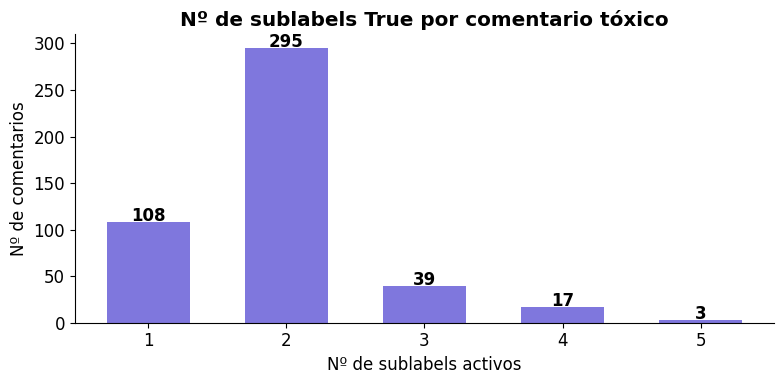

In [16]:
# Solapamiento: ¿Cuántos comentarios tienen múltiples labels True?
df['n_labels'] = df[sublabels_viables[1:]].astype(int).sum(axis=1)  # excluye IsToxic

fig, ax = plt.subplots(figsize=(8, 4))
label_dist = df[df['IsToxic']==True]['n_labels'].value_counts().sort_index()
ax.bar(label_dist.index, label_dist.values, color='#7F77DD', width=0.6)
ax.set_title('Nº de sublabels True por comentario tóxico', fontweight='bold')
ax.set_xlabel('Nº de sublabels activos')
ax.set_ylabel('Nº de comentarios')
for x, y in zip(label_dist.index, label_dist.values):
    ax.text(x, y + 1, str(y), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/v2/05_multilabel_overlap.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# ── CONCLUSIÓN CORRELACIÓN ──────────────────────────────────────────────────
print("""
CONCLUSIÓN 6 — Correlación entre sublabels:
- IsToxic = OR lógico exacto de todos los sublabels (crosstab confirmado)
- IsAbusive tiene la mayor correlación con IsToxic (esperado, es el más frecuente)
- Correlación IsRacist ↔ IsHatespeech: 0.94 (¿son redundantes?)
- Mayoría de comentarios tóxicos tienen 2 sublabel(s) activos

DECISIÓN MULTILABEL vs BINARIO:
□ Binario (IsToxic): más simple, suficiente para nivel esencial/medio
□ Multilabel (5 sublabels): más informativo, mejor para la app YouTube
→ DECISIÓN FINAL DEL EQUIPO: Binario para predecir y multilabel para la etiqueta.
""")



CONCLUSIÓN 6 — Correlación entre sublabels:
- IsToxic = OR lógico exacto de todos los sublabels (crosstab confirmado)
- IsAbusive tiene la mayor correlación con IsToxic (esperado, es el más frecuente)
- Correlación IsRacist ↔ IsHatespeech: 0.94 (¿son redundantes?)
- Mayoría de comentarios tóxicos tienen 2 sublabel(s) activos

DECISIÓN MULTILABEL vs BINARIO:
□ Binario (IsToxic): más simple, suficiente para nivel esencial/medio
□ Multilabel (5 sublabels): más informativo, mejor para la app YouTube
→ DECISIÓN FINAL DEL EQUIPO: Binario para predecir y multilabel para la etiqueta.



## 7. Análisis por VideoId (Por ahora no tiene relevancia)

¿Algunos vídeos tienen más comentarios de odio? ¿El origen del vídeo sesga el dataset?


In [18]:
video_stats = df.groupby('VideoId').agg(
    total_comments=('Text', 'count'),
    toxic_comments=('IsToxic', 'sum'),
).reset_index()
video_stats['toxic_rate'] = (video_stats['toxic_comments'] / video_stats['total_comments'] * 100).round(1)
video_stats = video_stats.sort_values('toxic_rate', ascending=False)

print(f"Vídeos únicos en el dataset: {df['VideoId'].nunique()}")
print()
print(video_stats.to_string(index=False))


Vídeos únicos en el dataset: 13

    VideoId  total_comments  toxic_comments  toxic_rate
cT14IbTDW2c             146             108        74.0
04kJtp6pVXI             172             111        64.5
8HB18hZrhXc              38              23        60.5
Dt9-byUhPdg              34              17        50.0
dDbRyFIkNII              10               5        50.0
TZxEyoplYbI             104              50        48.1
bUgKZMSxr3E              39              18        46.2
5vF4si3hoRA               8               3        37.5
9pr1oE34bIM             274              88        32.1
     #NAME?              16               5        31.2
4rCweDxDqdw              37              10        27.0
XRuCW80L9mA              10               2        20.0
dG7mZQvaQDk             112              22        19.6


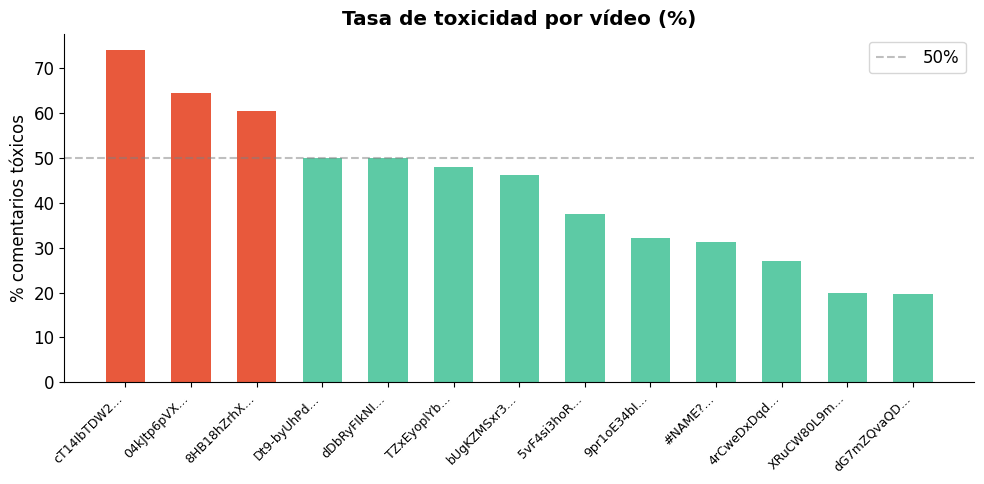

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E8593C' if r > 50 else '#5DCAA5' for r in video_stats['toxic_rate']]
bars = ax.bar(range(len(video_stats)), video_stats['toxic_rate'], color=colors, width=0.6)
ax.set_xticks(range(len(video_stats)))
ax.set_xticklabels([v[:10]+'...' for v in video_stats['VideoId']], rotation=45, ha='right', fontsize=9)
ax.set_title('Tasa de toxicidad por vídeo (%)', fontweight='bold')
ax.set_ylabel('% comentarios tóxicos')
ax.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/v2/06_toxicidad_por_video.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Análisis cualitativo — Muestra de comentarios

Leer ejemplos reales del dataset para entender el contexto lingüístico antes de modelar.


In [20]:
print("=== COMENTARIOS TÓXICOS (muestra) ===\n")
for i, row in df[df['IsToxic']==True].sample(5, random_state=42).iterrows():
    labels_activos = [col for col in sublabels_viables[1:] if row[col]]
    print(f"Labels: {labels_activos}")
    print(f"Texto: {row['Text'][:200]}")
    print("-" * 60)

print("\n=== COMENTARIOS NO TÓXICOS (muestra) ===\n")
for i, row in df[df['IsToxic']==False].sample(5, random_state=42).iterrows():
    print(f"Texto: {row['Text'][:200]}")
    print("-" * 60)


=== COMENTARIOS TÓXICOS (muestra) ===

Labels: ['IsHatespeech', 'IsRacist']
Texto: whites are weak
------------------------------------------------------------
Labels: ['IsAbusive', 'IsHatespeech', 'IsRacist']
Texto: Masri is a total idiot "I don't have to know the evidence, I can just come to my own conclusions instead"
Here is a clue, dont attack a cop and try to take his gun and then rush him after he finally g
------------------------------------------------------------
Labels: ['IsAbusive']
Texto: Racial profiling and police intimidation? He robbed a store and got killed as a result. Fucking excuses man. Black people shouldn't have to get arrested when they commit a strong arm robbery. When bla
------------------------------------------------------------
Labels: ['IsAbusive', 'IsProvocative']
Texto: So the autopsy showed a number of wounds to the right arm making the scenario of him being shot with his hands raised a lot less likely. Or are we still trying to claim that? Let's see

In [21]:
# Comentarios ambiguos / difíciles de clasificar
# (cortos, sin contexto, o borderline)
short_toxic = df[(df['IsToxic']==True) & (df['word_count'] < 5)]
print(f"Comentarios tóxicos con menos de 5 palabras: {len(short_toxic)}")
print()
for _, row in short_toxic.head(5).iterrows():
    print(f"  '{row['Text']}'")


Comentarios tóxicos con menos de 5 palabras: 39

  'Massri needs an education.'
  'CNN is such Bullcrap!'
  'FAKE!!...CNN IS BS'
  'Yep a Muslim bitch'
  'Masri is unemployed'


## 9. Resumen de conclusiones y decisiones

Documento final del EDA. Rellena cada sección con lo que encontraste.


In [22]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           RESUMEN EDA — DECISIONES PARA EL PROYECTO          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ DATASET                                                      ║
║   Shape:          1000 × 15                                  ║
║   Nulos:          0                                          ║
║   Duplicados:     0                                          ║
║   Chars. raros:   203 (acción: limpiar con regex  )          ║
║                                                              ║
║ TARGET                                                       ║
║   IsToxic True:   46% → BALANCEADO                           ║
║   Sublabels OK:   IsAbusive, IsProvocative, IsHatespeech,    ║
║                   IsRacist, IsObscene                        ║
║   Sublabels out:  IsHomophobic=0, IsRadicalism=0, IsSexist=1 ║
║                                                              ║
║ TEXTO                                                        ║
║   Longitud media: 185 chars / 35 words                       ║
║   Alta varianza   → truncado necesario en TF-IDF             ║
║   Outliers:       algunos comentarios >2000 chars            ║
║                                                              ║
║ DECISIONES                                                   ║
║   Modo:           BINARIO (IsToxic) ← Solo para separación   ║
║                MULTILABEL ← para etiqueta y reentrenamiento  ║
║   class_weight:   'balanced' en todos los modelos            ║
║   TF-IDF:         max_features=10000, ngram_range=(1,2)      ║
║   Métrica clave:  F1-weighted (dataset casi balanceado)      ║
║   Preprocesamiento: regex + NLTK stopwords + spaCy lemma     ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║           RESUMEN EDA — DECISIONES PARA EL PROYECTO          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║ DATASET                                                      ║
║   Shape:          1000 × 15                                  ║
║   Nulos:          0                                          ║
║   Duplicados:     0                                          ║
║   Chars. raros:   203 (acción: limpiar con regex  )          ║
║                                                              ║
║ TARGET                                                       ║
║   IsToxic True:   46% → BALANCEADO                           ║
║   Sublabels OK:   IsAbusive, IsProvocative, IsHatespeech,    ║
║                   IsRacist, IsObscene                        ║
║   Sublabels out:  IsHomophobic=0, IsRadicalism=0, IsSexist=1 ║
║                       

In [23]:
# Guardar dataset con columnas auxiliares para usar en las siguientes fases
df_clean = df.copy()
# Guardamos char_length y word_count por si son útiles como features adicionales
df_clean.to_csv('../data/processed/v2/comments_with_stats.csv', index=False)
print("✅ Dataset con estadísticas guardado en data/processed/comments_with_stats.csv")


✅ Dataset con estadísticas guardado en data/processed/comments_with_stats.csv
